# Exploratory Data Analysis

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

path = os.getcwd()
df = pd.read_csv( path+"//dmt_data.csv", index_col=False )

In [14]:
display( df.head() )

,Unnamed: 0,DMT-Previous Experiences,Mean-PSD-pre-alpha,Mean-PSD-pre-beta,Mean-PSD-pre-delta,Mean-PSD-pre-gamma1,Mean-PSD-pre-gamma2,Mean-PSD-pre-theta,Mean-PSD-dmt-alpha,Mean-PSD-dmt-beta,...,Mean-PSD-dmt-gamma1,Mean-PSD-dmt-gamma2,Mean-PSD-dmt-theta,Coherence-P8-Cz-beta,Coherence-P8-Pz-beta,Coherence-F7-Cz-gamma1,Coherence-F8-Pz-gamma1,Coherence-F8-POz-gamma1,Coherence-M1-CPz-gamma2,Mean-spectral-entropy
0,0,1,0.669,0.036,0.152,0.009,0.004,0.100,0.465,0.060,...,0.022,0.018,0.126,0.040,0.040,0.030,0.029,0.021,0.018,3.874
1,1,1,0.403,0.085,0.351,0.009,0.007,0.116,0.234,0.100,...,0.035,0.031,0.140,0.055,0.066,0.016,0.006,0.014,0.018,4.348
2,2,1,0.234,0.127,0.355,0.043,0.028,0.184,0.117,0.103,...,0.023,0.013,0.177,0.079,0.082,0.012,0.024,0.047,0.014,4.191
3,3,1,0.284,0.044,0.414,0.011,0.006,0.211,0.063,0.069,...,0.039,0.037,0.185,0.036,0.014,0.035,0.046,0.042,0.009,3.970
4,4,0,0.425,0.051,0.314,0.024,0.023,0.133,0.203,0.060,...,0.045,0.040,0.148,0.001,0.004,0.023,0.008,0.029,0.000,4.559


In [47]:
y = df['DMT-Previous Experiences']
X = df.drop( columns='DMT-Previous Experiences' )

# Correlations

,Unnamed: 0,Mean-PSD-pre-alpha,Mean-PSD-pre-beta,Mean-PSD-pre-delta,Mean-PSD-pre-gamma1,Mean-PSD-pre-gamma2,Mean-PSD-pre-theta,Mean-PSD-dmt-alpha,Mean-PSD-dmt-beta,Mean-PSD-dmt-delta,Mean-PSD-dmt-gamma1,Mean-PSD-dmt-gamma2,Mean-PSD-dmt-theta,Coherence-P8-Cz-beta,Coherence-P8-Pz-beta,Coherence-F7-Cz-gamma1,Coherence-F8-Pz-gamma1,Coherence-F8-POz-gamma1,Coherence-M1-CPz-gamma2,Mean-spectral-entropy
Point-Biserial Correlation,0.14032,0.203537,0.221899,-0.219093,-0.190525,-0.271034,-0.065712,-0.073884,0.286512,0.091009,-0.064476,-0.070584,-0.120048,0.513154,0.504135,0.252994,0.508922,0.439731,0.514933,0.115095


,Unnamed: 0,Mean-PSD-pre-alpha,Mean-PSD-pre-beta,Mean-PSD-pre-delta,Mean-PSD-pre-gamma1,Mean-PSD-pre-gamma2,Mean-PSD-pre-theta,Mean-PSD-dmt-alpha,Mean-PSD-dmt-beta,Mean-PSD-dmt-delta,Mean-PSD-dmt-gamma1,Mean-PSD-dmt-gamma2,Mean-PSD-dmt-theta,Coherence-P8-Cz-beta,Coherence-P8-Pz-beta,Coherence-F7-Cz-gamma1,Coherence-F8-Pz-gamma1,Coherence-F8-POz-gamma1,Coherence-M1-CPz-gamma2,Mean-spectral-entropy
p-value,0.476348,0.29888,0.256433,0.262649,0.331483,0.162997,0.739721,0.708669,0.139368,0.645103,0.744456,0.721155,0.542868,0.005229,0.00623,0.193967,0.00568,0.019208,0.005049,0.559758


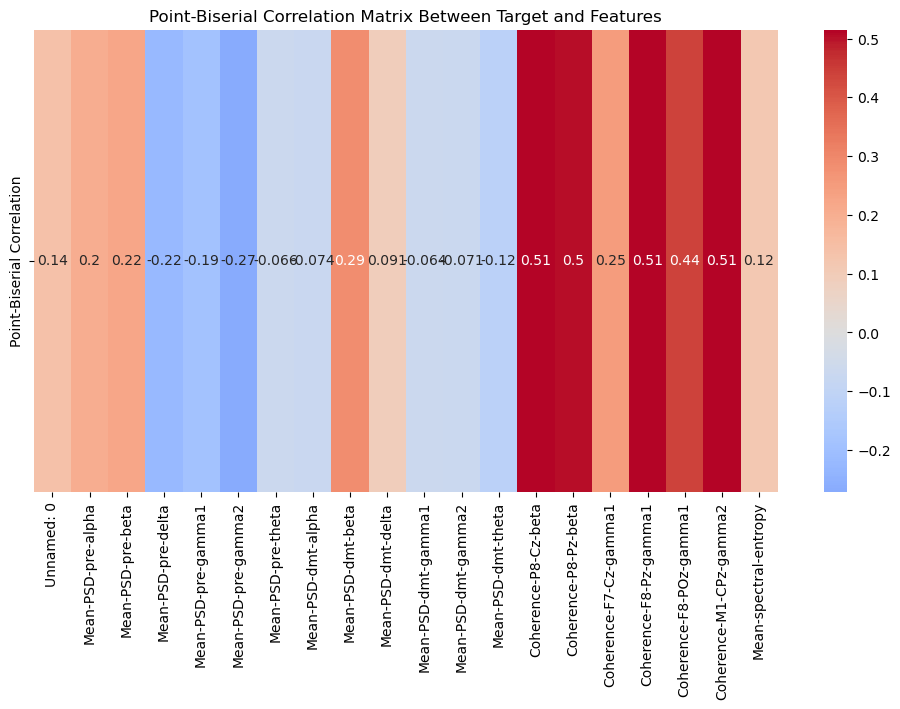

In [16]:
from scipy.stats import pointbiserialr
import seaborn as sns

correlations = {}
p_values = {}

for col in X.columns:
    corr, p_value = pointbiserialr( y, df[col] )
    correlations[col] = corr
    p_values[col] = p_value

corr = pd.DataFrame( correlations, index=['Point-Biserial Correlation'] )
corr_p_value = pd.DataFrame( p_values, index=['p-value'] )
display( corr )
display( corr_p_value )

plt.figure( figsize=(12, 6) )
sns.heatmap( corr, annot=True, cmap='coolwarm', center=0 )
plt.title( 'Point-Biserial Correlation Matrix Between Target and Features' )
plt.show()


# 1. Logistic Regression

# 1.1 Model Selection and Hyperparameter Tuning

In [48]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split( X.values, y.values, test_size=0.2, stratify=y, random_state=42 )
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform( X_train )
X_test_scaled = scaler.transform( X_test )

# logreg = LogisticRegression( solver='liblinear', max_iter=10000, random_state=42 )
# logreg.fit( X_train_scaled, y_train )
# param_grid = {
#     'C': [0.001, 0.01, 0.1, 1, 10, 100],
#     'penalty': ['l1', 'l2']
#     }

# grid_search_logreg = GridSearchCV(
#     estimator=logreg,
#     param_grid=param_grid,
#     cv=5,
#     scoring='accuracy',
#     n_jobs=-1
#     )

# grid_search_logreg.fit( X_train_scaled, y_train )
# best_params = grid_search_logreg.best_params_
# print( f"Best parameters: {best_params}" )

# best_log_reg = grid_search_logreg.best_estimator_


In [65]:
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipe_logreg = Pipeline([
    ( 'scaler', StandardScaler() ),
    ('logistic_regression', LogisticRegression( solver='liblinear', random_state= 42 ) )
])

loo = LeaveOneOut()

param_grid_logreg = {
    'logistic_regression__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logistic_regression__penalty': ['l1', 'l2']
    }

grid_search_logreg = GridSearchCV(
    estimator = pipe_logreg,
    param_grid = param_grid_logreg,
    cv = loo,
    scoring = 'accuracy',
    n_jobs = -1
    )

grid_search_logreg.fit( X.values, y.values )
best_params_logreg = grid_search_logreg.best_params_
print( f"Best parameters: {best_params_logreg}" )

best_logreg = grid_search_logreg.best_estimator_

Best parameters: {'logistic_regression__C': 0.1, 'logistic_regression__penalty': 'l2'}


In [36]:
print( best_logreg.named_steps )

{'scaler': StandardScaler(), 'logistic_regression': LogisticRegression(C=0.1, random_state=42, solver='liblinear')}


# 1.2 Evaluate model performance

In [7]:
from sklearn.metrics import confusion_matrix, classification_report

# y_pred = best_log_reg.predict( X_test_scaled )
# y_pred_proba = best_log_reg.predict_proba( X_test_scaled )[:, 1]
# confusion = confusion_matrix( y_test, y_pred )
# print( f"Confusion matrix: \n{confusion}" )
# print()
# print( classification_report( y_test, y_pred, target_names=['one-time', 'multiple-time'] ) )

Confusion matrix: 
[[0 2]
 [0 4]]

               precision    recall  f1-score   support

     one-time       0.00      0.00      0.00         2
multiple-time       0.67      1.00      0.80         4

     accuracy                           0.67         6
    macro avg       0.33      0.50      0.40         6
 weighted avg       0.44      0.67      0.53         6



/home/yijun-wu/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/yijun-wu/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/yijun-wu/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [74]:
from sklearn.metrics import confusion_matrix, classification_report

y_true_logreg = []
y_pred_logreg = []
y_proba_logreg = []
X_test_scaled = []

for train_index, test_index in loo.split( X.values ):
    X_train, X_test = X.values[train_index], X.values[test_index]
    y_train, y_test = y.values[train_index], y.values[test_index]
    best_logreg.fit( X_train, y_train )
    pred = best_logreg.predict( X_test )
    prob = best_logreg.predict_proba( X_test )[:, 1]
    X_test_scaled.append( X_test[0] )
    y_true_logreg.append( y_test[0] )
    y_pred_logreg.append( pred[0] )
    y_proba_logreg.append( prob[0] )

X_test_scaled = np.array( X_test_scaled )
# y_true_logreg = np.array ( y_true_logreg )
# y_pred_logreg = np.array( y_pred_logreg )
confusion = confusion_matrix( y_true_logreg, y_pred_logreg )
print( f"Confusion matrix: \n{confusion}" )
print()
print( classification_report( y_true_logreg, y_pred_logreg, target_names = ['one-time', 'multiple-time'] ) )

Confusion matrix: 
[[ 9  2]
 [ 2 15]]

               precision    recall  f1-score   support

     one-time       0.82      0.82      0.82        11
multiple-time       0.88      0.88      0.88        17

     accuracy                           0.86        28
    macro avg       0.85      0.85      0.85        28
 weighted avg       0.86      0.86      0.86        28



In [75]:
print( X_test_scaled )

[[0.000e+00 6.690e-01 3.600e-02 1.520e-01 9.000e-03 4.000e-03 1.000e-01
  4.650e-01 6.000e-02 2.780e-01 2.200e-02 1.800e-02 1.260e-01 4.000e-02
  4.000e-02 3.000e-02 2.900e-02 2.100e-02 1.800e-02 3.874e+00]
 [1.000e+00 4.030e-01 8.500e-02 3.510e-01 9.000e-03 7.000e-03 1.160e-01
  2.340e-01 1.000e-01 4.310e-01 3.500e-02 3.100e-02 1.400e-01 5.500e-02
  6.600e-02 1.600e-02 6.000e-03 1.400e-02 1.800e-02 4.348e+00]
 [2.000e+00 2.340e-01 1.270e-01 3.550e-01 4.300e-02 2.800e-02 1.840e-01
  1.170e-01 1.030e-01 5.380e-01 2.300e-02 1.300e-02 1.770e-01 7.900e-02
  8.200e-02 1.200e-02 2.400e-02 4.700e-02 1.400e-02 4.191e+00]
 [3.000e+00 2.840e-01 4.400e-02 4.140e-01 1.100e-02 6.000e-03 2.110e-01
  6.300e-02 6.900e-02 5.770e-01 3.900e-02 3.700e-02 1.850e-01 3.600e-02
  1.400e-02 3.500e-02 4.600e-02 4.200e-02 9.000e-03 3.970e+00]
 [4.000e+00 4.250e-01 5.100e-02 3.140e-01 2.400e-02 2.300e-02 1.330e-01
  2.030e-01 6.000e-02 4.740e-01 4.500e-02 4.000e-02 1.480e-01 1.000e-03
  4.000e-03 2.300e-02 8.000e

# 1.3 Visualize results

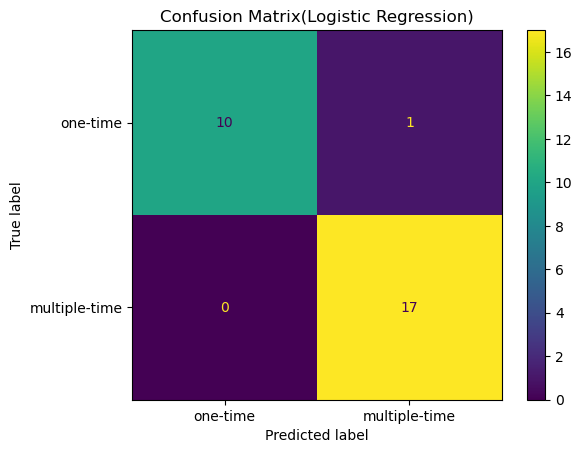

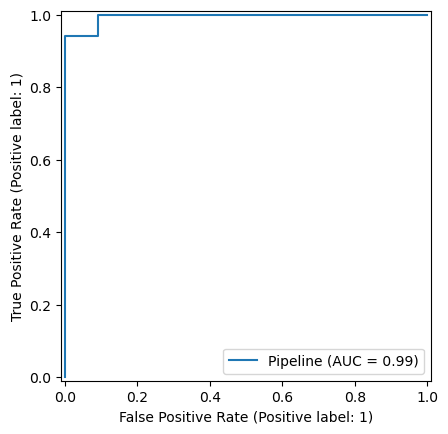

In [76]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve, RocCurveDisplay, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator( best_logreg, X_test_scaled, y_true_logreg, display_labels = ['one-time', 'multiple-time'] )
plt.title( 'Confusion Matrix(Logistic Regression)' )
plt.show()

RocCurveDisplay.from_estimator( best_logreg, X_test_scaled, y_true_logreg )
plt.show()
    
# confusion_disp.plot()
# plt.title( 'Confusion Matrix(Logistic Regression)' )
# plt.show()

# fpr, tpr, thresholds = roc_curve( y_test, y_pred_proba )
# roc_auc = auc( fpr, tpr )
# RocCurveDisplay.from_estimator( best_log_reg, X_test_scaled, y_test )
# plt.show()


# 1.4 Feature Importance Analysis

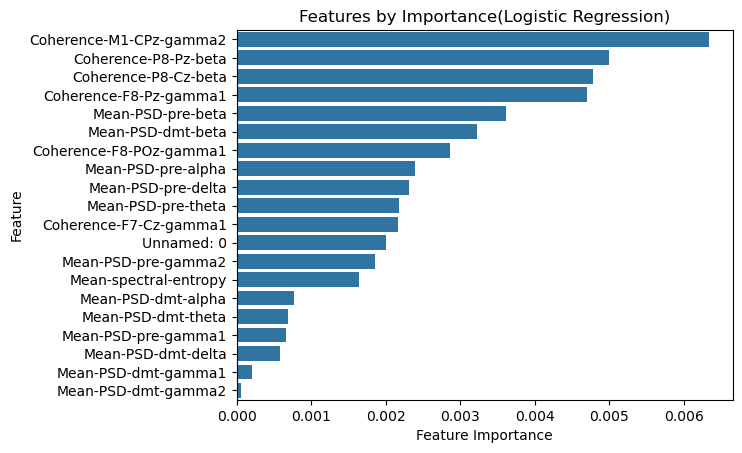

In [31]:
import seaborn as sns

coefficients = best_log_reg.coef_[0]
feature_importance = pd.DataFrame( {'Feature': X.columns, 'Coefficient': coefficients} )
feature_importance['Abs_Coefficient'] = abs( feature_importance['Coefficient'] )
feature_importance = feature_importance.sort_values( 'Abs_Coefficient', ascending=False )

sns.barplot( y='Feature', x='Abs_Coefficient', data=feature_importance )
plt.title( 'Features by Importance(Logistic Regression)' )
plt.xlabel( "Feature Importance" )
plt.show()

# 1.5 Statistical Significance Testing

In [10]:
# from sklearn.model_selection import permutation_test_score

# # Perform permutation test
# score, perm_scores, pvalue = permutation_test_score(
#     best_log_reg, X_train_scaled, y_train, 
#     scoring="accuracy", cv=5, n_permutations=1000
# )

# print(f"Model accuracy: {score:.4f}")
# print(f"Permutation accuracy scores mean: {perm_scores.mean():.4f}")
# print(f"P-value: {pvalue:.4f}")

# # Plot permutation test results
# plt.figure(figsize=(10, 6))
# plt.hist(perm_scores, bins=20, edgecolor='black')
# plt.axvline(score, color='red', linestyle='--', label=f'Accuracy = {score:.4f}')
# plt.xlabel('Accuracy')
# plt.ylabel('Frequency')
# plt.title('Permutation Test Results')
# plt.legend()
# plt.show()

# 2. Support Vector Machine(SVM)

# 2.1 Model Selection and Hyperparameter Tuning

In [49]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid_svc = [
    {'kernel': ['linear'], 'C': [0.01, 0.1, 1, 10, 100]},
    {'kernel': ['rbf'], 'C': [0.01, 0.1, 1, 10, 100], 'gamma': [0.01, 0.1, 1, 10]}
]

grid_search_svc = GridSearchCV(
    SVC( probability=True, random_state=42 ),
    param_grid=param_grid_svc,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_svc.fit(X_train_scaled, y_train)

best_params_svc = grid_search_svc.best_params_
print(f"Best parameters: {best_params_svc}")

best_svm = grid_search_svc.best_estimator_

Best parameters: {'C': 0.1, 'kernel': 'linear'}


# 2.2 Model Evaluation

In [27]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_svm = best_svm.predict( X_test_scaled )
y_pred_proba_svm = best_svm.predict_proba( X_test_scaled )[:, 1]
confusion = confusion_matrix( y_test, y_pred_svm )
print( f"Confusion matrix: \n{confusion}" )
print()
print( classification_report( y_test, y_pred_svm, target_names=['one-time', 'multiple-time'] ) )

Confusion matrix: 
[[2 0]
 [0 4]]

               precision    recall  f1-score   support

     one-time       1.00      1.00      1.00         2
multiple-time       1.00      1.00      1.00         4

     accuracy                           1.00         6
    macro avg       1.00      1.00      1.00         6
 weighted avg       1.00      1.00      1.00         6



In [51]:
print( y_test )
print( X_test_scaled )

[1 1 1 0 1 0]
[[-1.38119469e+00 -1.20537043e+00 -9.04177917e-01  1.38979269e+00
  -6.48474105e-01 -7.83082764e-01  7.48905010e-01 -1.50584987e+00
  -3.45126203e-01  1.57838907e+00 -2.86077587e-02  2.13465724e-01
   3.38968801e-01 -2.55026039e-01 -1.00431334e+00  4.78341641e-02
   1.38540668e+00  1.38874095e+00 -7.61066196e-01 -4.80868721e-01]
 [-1.50624112e+00 -1.61221531e+00  2.70857674e+00  7.70091244e-01
   3.06311752e+00  2.60095347e+00  3.19098656e-01 -1.02430219e+00
   5.70314932e-01  1.19808639e+00 -6.57978450e-01 -8.39897847e-01
   1.62464337e-01  1.18961248e+00  1.61320017e+00 -6.43711180e-01
   1.27363841e-01  1.76969233e+00 -3.95488547e-01 -6.05480518e-03]
 [ 1.19362504e-01 -5.78829310e-01 -6.86542095e-01 -5.11325308e-01
  -5.32486867e-01 -7.83082764e-01  2.29302413e+00 -4.80331655e-01
  -7.22072553e-01 -4.10886454e-01 -3.43293104e-01 -4.00996359e-01
   3.11891412e+00 -2.55026039e-01  1.61320017e+00  6.49177942e-01
   2.01442810e+00  3.75063951e+00  6.28128869e-01  4.1211738

In [29]:
print( best_svm.predict_proba( X_test_scaled ) )
print( y_pred_proba_svm )

[[0.4099777  0.5900223 ]
 [0.2504298  0.7495702 ]
 [0.06499982 0.93500018]
 [0.61342206 0.38657794]
 [0.04630148 0.95369852]
 [0.97948712 0.02051288]]
[0.5900223  0.7495702  0.93500018 0.38657794 0.95369852 0.02051288]


# 2.3 Visualizaton of Results

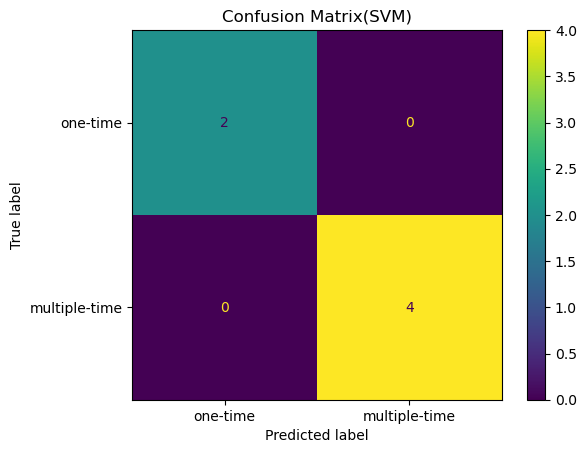

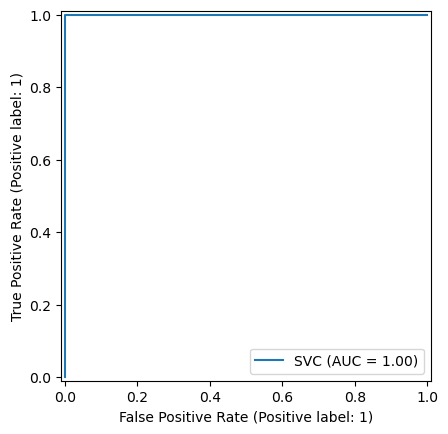

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve, RocCurveDisplay, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator( best_svm, X_test_scaled, y_test, display_labels=['one-time', 'multiple-time'] )
plt.title( 'Confusion Matrix(SVM)' )
plt.show()

fpr, tpr, thresholds = roc_curve( y_test, y_pred_proba_svm )
roc_auc = auc( fpr, tpr )
RocCurveDisplay.from_estimator( best_svm, X_test_scaled, y_test )
plt.show()

In [36]:
print( thresholds )

[       inf 0.95369852 0.5900223  0.02051288]


# 2.4 Feature Importance Analysis

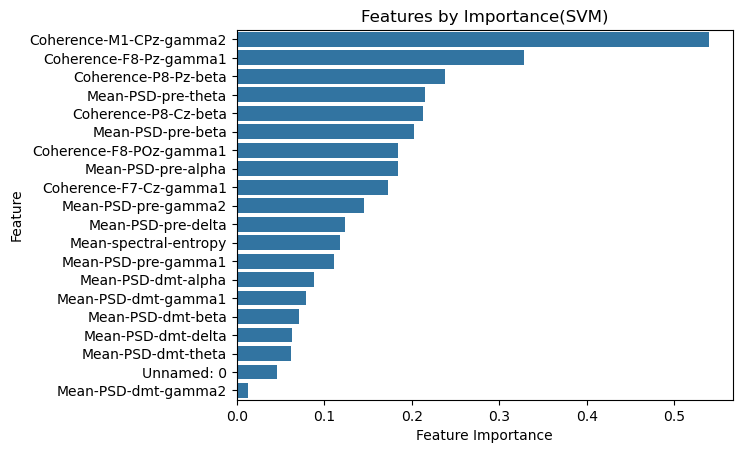

In [14]:
import seaborn as sns

coefficients = best_svm.coef_[0]
feature_importance = pd.DataFrame( {'Feature': X.columns, 'Coefficient': coefficients} )
feature_importance['Abs_Coefficient'] = abs( feature_importance['Coefficient'] )
feature_importance = feature_importance.sort_values( 'Abs_Coefficient', ascending=False )

sns.barplot( y='Feature', x='Abs_Coefficient', data=feature_importance )
plt.title( 'Features by Importance(SVM)' )
plt.xlabel( "Feature Importance" )
plt.show()

# 3. Random Forest

# 3.1 Model Selection and Hyperparameter Tuning

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier( random_state=42 )
param_grid_rf = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs = -1
)

grid_search_rf.fit( X_train_scaled, y_train )

best_params_rf = grid_search_rf.best_params_
print(f"Best parameters: {best_params_rf}")

best_rf = grid_search_rf.best_estimator_

Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}


# 3.2 Model Evaluation

In [16]:
y_pred_rf = best_rf.predict( X_test_scaled )
y_pred_proba_rf = best_rf.predict_proba( X_test_scaled )[:, 1]
confusion = confusion_matrix( y_test, y_pred_rf )
print( f"Confusion matrix: \n{confusion}" )
print()
print( classification_report( y_test, y_pred_rf, target_names=['one-time', 'multiple-time'] ) )

Confusion matrix: 
[[2 0]
 [1 3]]

               precision    recall  f1-score   support

     one-time       0.67      1.00      0.80         2
multiple-time       1.00      0.75      0.86         4

     accuracy                           0.83         6
    macro avg       0.83      0.88      0.83         6
 weighted avg       0.89      0.83      0.84         6



# 3.3 Visualization of Results

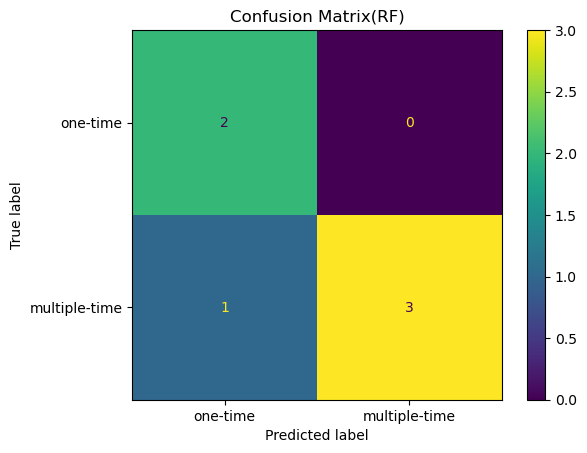

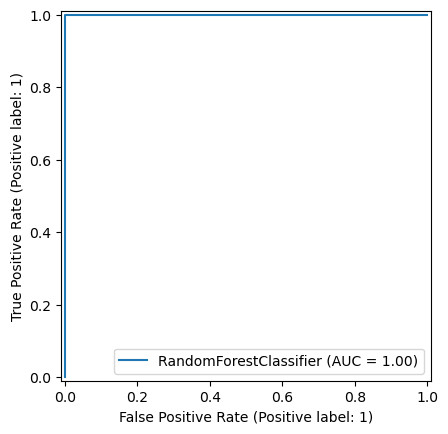

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve, RocCurveDisplay, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator( best_rf, X_test_scaled, y_test, display_labels=['one-time', 'multiple-time'] )
plt.title( 'Confusion Matrix(RF)' )
plt.show()

fpr, tpr, thresholds = roc_curve( y_test, y_pred_proba_rf )
roc_auc = auc( fpr, tpr )
RocCurveDisplay.from_estimator( best_rf, X_test_scaled, y_test )
plt.show()

# 3.4 Feature Importance Analysis

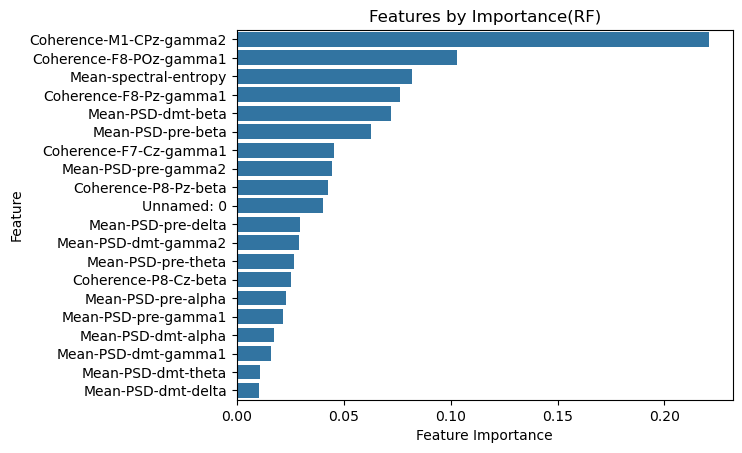

In [18]:
importances = best_rf.feature_importances_
feature_names = X.columns

feat_imp_df = pd.DataFrame( {"Feature": feature_names, "Feature Importance": importances} )
feat_imp_df = feat_imp_df.sort_values( 'Feature Importance', ascending=False )

sns.barplot( y='Feature', x='Feature Importance', data=feat_imp_df )
plt.title( 'Features by Importance(RF)' )
plt.show()

# 4. GradientBoosting

# 4.1 Model Selection and Hyperparameter Tuning

In [19]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

gb = GradientBoostingClassifier( random_state=42 )
param_grid_gb = {
    'n_estimators': [10, 50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid_gb,
    cv = 5,
    scoring='accuracy',
    n_jobs = -1
)

grid_search_gb.fit( X_train_scaled, y_train )
print("Best parameters:", grid_search_gb.best_params_)
best_gb = grid_search_gb.best_estimator_

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}


# 4.2 Model Evaluation

In [20]:
y_pred_gb = best_gb.predict( X_test_scaled )
y_pred_proba_gb = best_gb.predict_proba( X_test_scaled )[:, 1]
confusion = confusion_matrix( y_test, y_pred_gb )
print( f"Confusion matrix: \n{confusion}" )
print()
print( classification_report( y_test, y_pred_gb, target_names=['one-time', 'multiple-time'] ) )

Confusion matrix: 
[[1 1]
 [1 3]]

               precision    recall  f1-score   support

     one-time       0.50      0.50      0.50         2
multiple-time       0.75      0.75      0.75         4

     accuracy                           0.67         6
    macro avg       0.62      0.62      0.62         6
 weighted avg       0.67      0.67      0.67         6



# 4.3 Visualization of Results

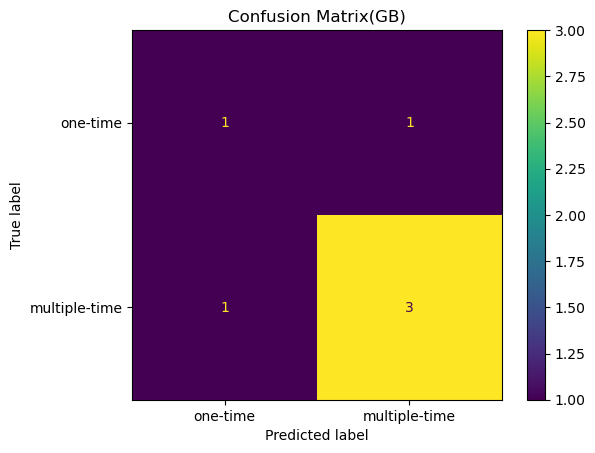

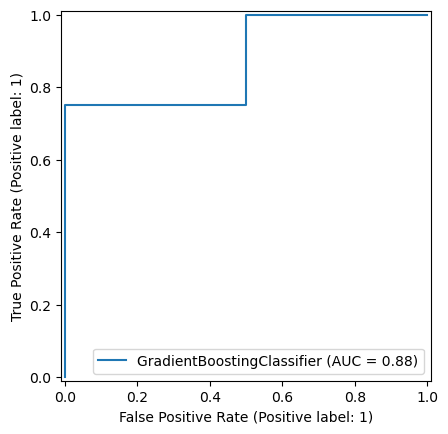

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve, RocCurveDisplay, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator( best_gb, X_test_scaled, y_test, display_labels=['one-time', 'multiple-time'] )
plt.title( 'Confusion Matrix(GB)' )
plt.show()

fpr, tpr, thresholds = roc_curve( y_test, y_pred_proba_gb )
roc_auc = auc( fpr, tpr )
RocCurveDisplay.from_estimator( best_gb, X_test_scaled, y_test )
plt.show()

# 4.4 Feature Importance Analysis

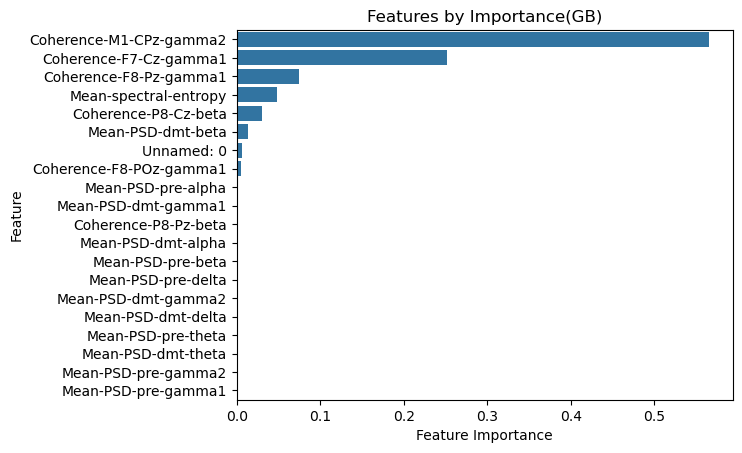

In [22]:
importances_gb = best_gb.feature_importances_
feature_names = X.columns

feat_imp_df = pd.DataFrame( {"Feature": feature_names, "Feature Importance": importances_gb} )
feat_imp_df = feat_imp_df.sort_values( 'Feature Importance', ascending=False )

sns.barplot( y='Feature', x='Feature Importance', data=feat_imp_df )
plt.title( 'Features by Importance(GB)' )
plt.show()

In [23]:
print( thresholds )

[           inf 9.99999987e-01 9.99989602e-01 9.99979764e-01
 9.54593344e-06 8.00525753e-08]
